In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
from model_evaluator import ModelEvaluator
from blue_blob_images_float import image_to_float
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess_input


In [2]:
blob_imgs  = image_to_float("blue_blob_test_images_subset")*255
galaxy_imgs = image_to_float("galaxies_test_images_subset")*255

print(f"Galaxy images shape: {galaxy_imgs.shape}, dtype: {galaxy_imgs.dtype}")
print(f"Blue-blob images shape: {blob_imgs.shape}, dtype: {blob_imgs.dtype}")

X_test_all = np.concatenate([galaxy_imgs, blob_imgs], axis=0)
y_galaxy = np.ones(galaxy_imgs.shape[0], dtype=np.int64)
y_blob   = np.zeros(blob_imgs.shape[0],   dtype=np.int64)
y_test_all = np.concatenate([y_galaxy, y_blob], axis=0)


Attempting to load JPEG images from: blue_blob_test_images_subset using TensorFlow/Keras
Expecting images of size: (256, 256)
Found 414 items in the directory. Processing valid JPEGs...

------------------------------------
Image loading successful!
Loaded 414 images.
Final NumPy array shape: (414, 256, 256, 3)
Data type of array elements: uint8
------------------------------------
Attempting to load JPEG images from: galaxies_test_images_subset using TensorFlow/Keras
Expecting images of size: (256, 256)
Found 354 items in the directory. Processing valid JPEGs...

------------------------------------
Image loading successful!
Loaded 354 images.
Final NumPy array shape: (354, 256, 256, 3)
Data type of array elements: uint8
------------------------------------
Galaxy images shape: (354, 256, 256, 3), dtype: float32
Blue-blob images shape: (414, 256, 256, 3), dtype: float32


In [3]:
X_test_copy_res = X_test_all.copy()
X_test_copy_effi = X_test_all.copy()
# Preprocess the images
X_test_resnet = resnet_preprocess_input(X_test_copy_res)


In [4]:
X_test_resnet

array([[[[-0.9607843 , -0.21568626, -0.372549  ],
         [-0.64705884, -0.14509803, -0.25490195],
         [-0.6392157 , -0.6392157 , -0.62352943],
         ...,
         [-0.46666664, -0.45098037, -0.49019605],
         [-0.3490196 , -0.58431375, -0.3960784 ],
         [-0.19215685, -0.5529412 , -0.26274508]],

        [[-1.        , -0.38039213, -0.5372549 ],
         [-0.6784314 , -0.2235294 , -0.3333333 ],
         [-0.5137255 , -0.4352941 , -0.44313723],
         ...,
         [-0.24705881, -0.1607843 , -0.2235294 ],
         [-0.42745095, -0.5764706 , -0.41960782],
         [-0.38039213, -0.64705884, -0.372549  ]],

        [[-0.88235295, -0.4352941 , -0.58431375],
         [-0.6       , -0.2235294 , -0.3333333 ],
         [-0.3333333 , -0.08235294, -0.12156862],
         ...,
         [-0.6       , -0.3960784 , -0.4980392 ],
         [-0.46666664, -0.44313723, -0.3098039 ],
         [-0.2862745 , -0.35686272, -0.11372548]],

        ...,

        [[-0.5764706 , -0.41176468, -0

24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 243ms/step


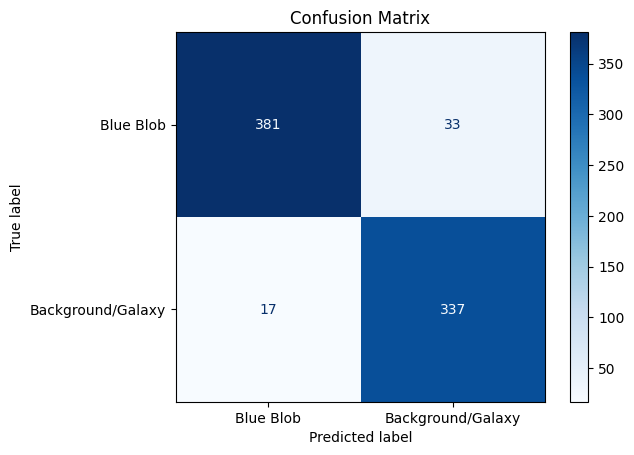

                   precision    recall  f1-score   support

        Blue Blob       0.96      0.92      0.94       414
Background/Galaxy       0.91      0.95      0.93       354

         accuracy                           0.93       768
        macro avg       0.93      0.94      0.93       768
     weighted avg       0.94      0.93      0.93       768



In [13]:
model = keras.models.load_model('resnet_50V2_mlp/epoch_20.keras')
evaluator = ModelEvaluator(model, 0.5)  
evaluator.predict_and_report(
    X_test_resnet, y_test_all)

Attempting to load JPEG images from: blue_blob_test_images_subset using TensorFlow/Keras
Expecting images of size: (256, 256)
Found 414 items in the directory. Processing valid JPEGs...

------------------------------------
Image loading successful!
Loaded 414 images.
Final NumPy array shape: (414, 256, 256, 3)
Data type of array elements: uint8
------------------------------------
Attempting to load JPEG images from: galaxies_test_images_subset using TensorFlow/Keras
Expecting images of size: (256, 256)
Found 354 items in the directory. Processing valid JPEGs...

------------------------------------
Image loading successful!
Loaded 354 images.
Final NumPy array shape: (354, 256, 256, 3)
Data type of array elements: uint8
------------------------------------
Galaxy images shape: (354, 256, 256, 3), dtype: float32
Blue-blob images shape: (414, 256, 256, 3), dtype: float32
Total test samples: 768
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 278ms/step


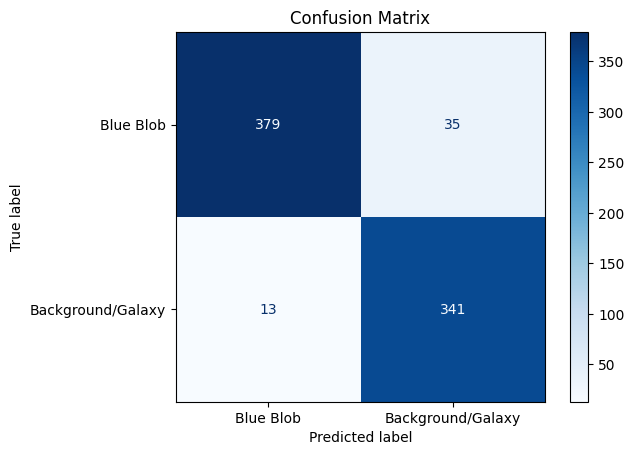

                   precision    recall  f1-score   support

        Blue Blob       0.97      0.92      0.94       414
Background/Galaxy       0.91      0.96      0.93       354

         accuracy                           0.94       768
        macro avg       0.94      0.94      0.94       768
     weighted avg       0.94      0.94      0.94       768

35 misclassified samples (true=0→pred=1)


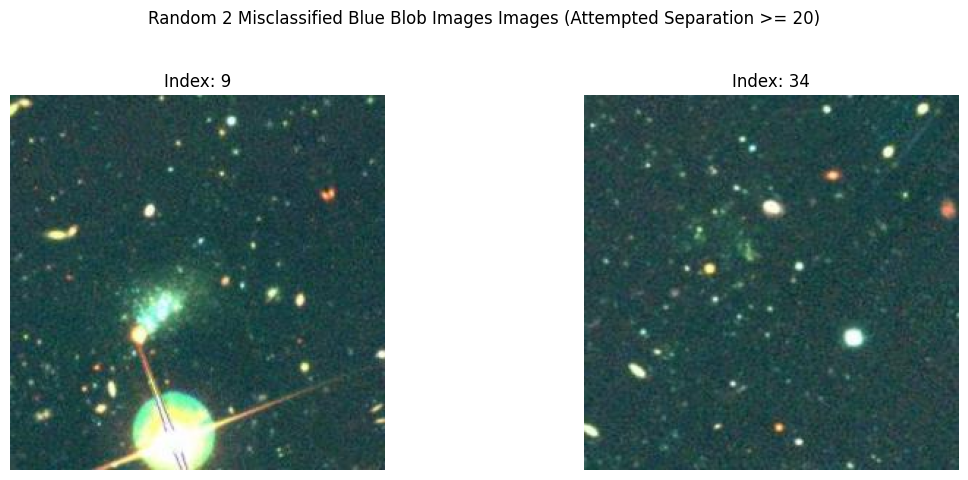

13 misclassified samples (true=1→pred=0)


/Users/swapnaneeldey/Desktop/MATH496T/Blue_blobs_GenAI/plotting_random_images.py:53: UserWarning: Could only find 1 indices with separation >= 20. Falling back to simple random sampling for the remaining.
  warnings.warn(f"Could only find {len(selected_indices)} indices with separation >= {min_separation}. "


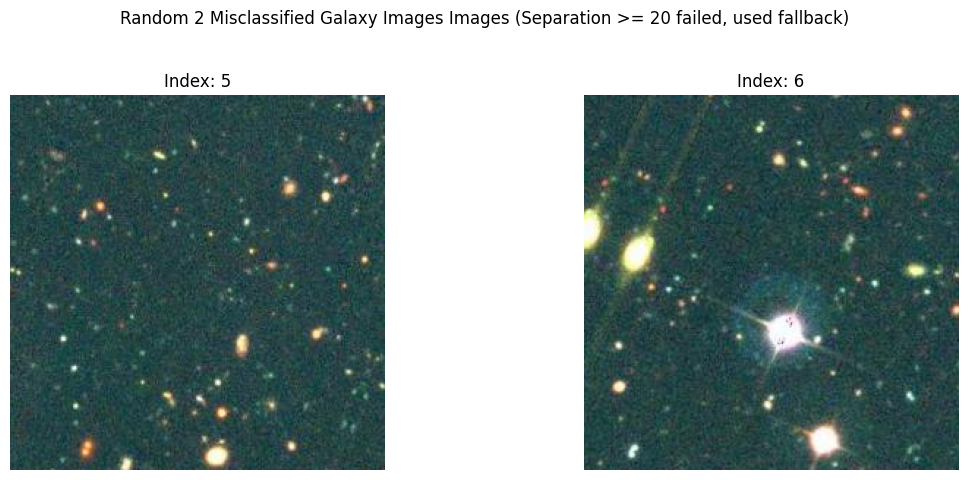

In [14]:
model = keras.models.load_model('final_models/blue_blob_galaxy_resnet_50V2_mlp_fine_tuned.keras')
evaluator = ModelEvaluator(model, 0.5)  
evaluator.evaluate(
    blob_dir="blue_blob_test_images_subset",
    galaxy_dir="galaxies_test_images_subset",
    X_test=X_test_resnet, 
    y_test=y_test_all,
    num_to_plot=2,
    min_separation=20)

## No head ResNet



Attempting to load JPEG images from: blue_blob_test_images_subset using TensorFlow/Keras
Expecting images of size: (256, 256)
Found 414 items in the directory. Processing valid JPEGs...

------------------------------------
Image loading successful!
Loaded 414 images.
Final NumPy array shape: (414, 256, 256, 3)
Data type of array elements: uint8
------------------------------------
Attempting to load JPEG images from: galaxies_test_images_subset using TensorFlow/Keras
Expecting images of size: (256, 256)
Found 354 items in the directory. Processing valid JPEGs...

------------------------------------
Image loading successful!
Loaded 354 images.
Final NumPy array shape: (354, 256, 256, 3)
Data type of array elements: uint8
------------------------------------
Galaxy images shape: (354, 256, 256, 3), dtype: float32
Blue-blob images shape: (414, 256, 256, 3), dtype: float32
Total test samples: 768
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 249ms/step


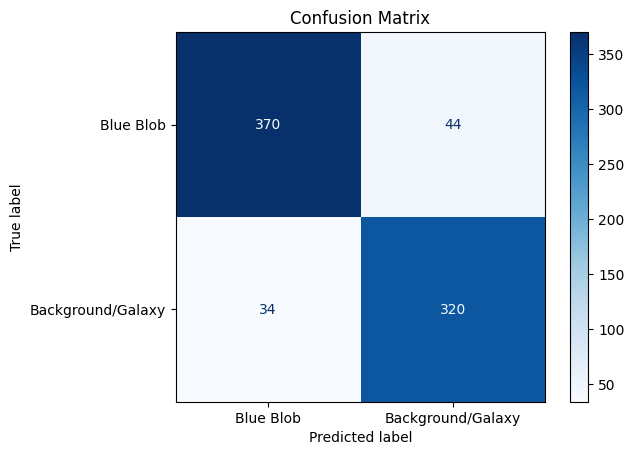

                   precision    recall  f1-score   support

        Blue Blob       0.92      0.89      0.90       414
Background/Galaxy       0.88      0.90      0.89       354

         accuracy                           0.90       768
        macro avg       0.90      0.90      0.90       768
     weighted avg       0.90      0.90      0.90       768

44 misclassified samples (true=0→pred=1)


/Users/swapnaneeldey/Desktop/MATH496T/Blue_blobs_GenAI/plotting_random_images.py:53: UserWarning: Could only find 2 indices with separation >= 20. Falling back to simple random sampling for the remaining.
  warnings.warn(f"Could only find {len(selected_indices)} indices with separation >= {min_separation}. "


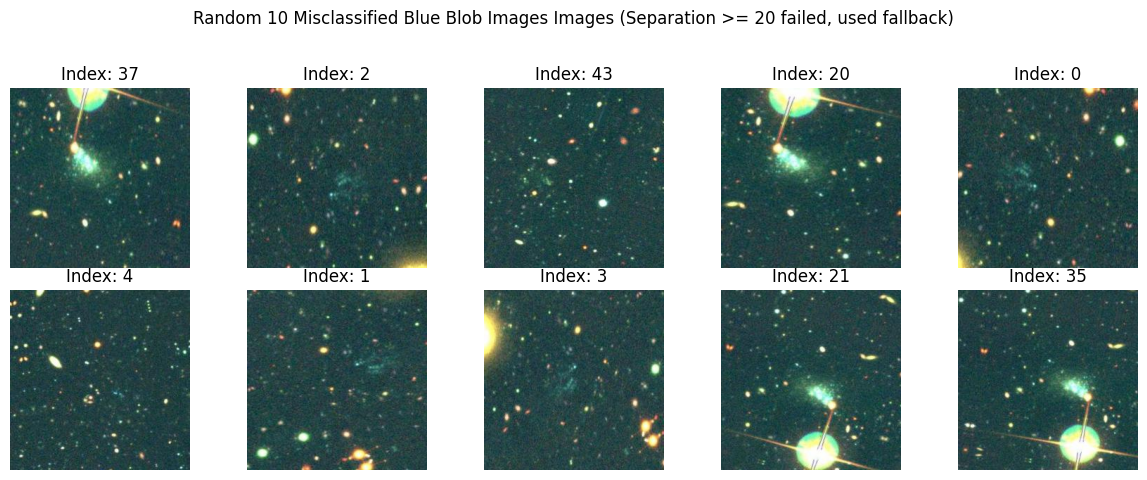

/Users/swapnaneeldey/Desktop/MATH496T/Blue_blobs_GenAI/plotting_random_images.py:53: UserWarning: Could only find 1 indices with separation >= 20. Falling back to simple random sampling for the remaining.
  warnings.warn(f"Could only find {len(selected_indices)} indices with separation >= {min_separation}. "


34 misclassified samples (true=1→pred=0)


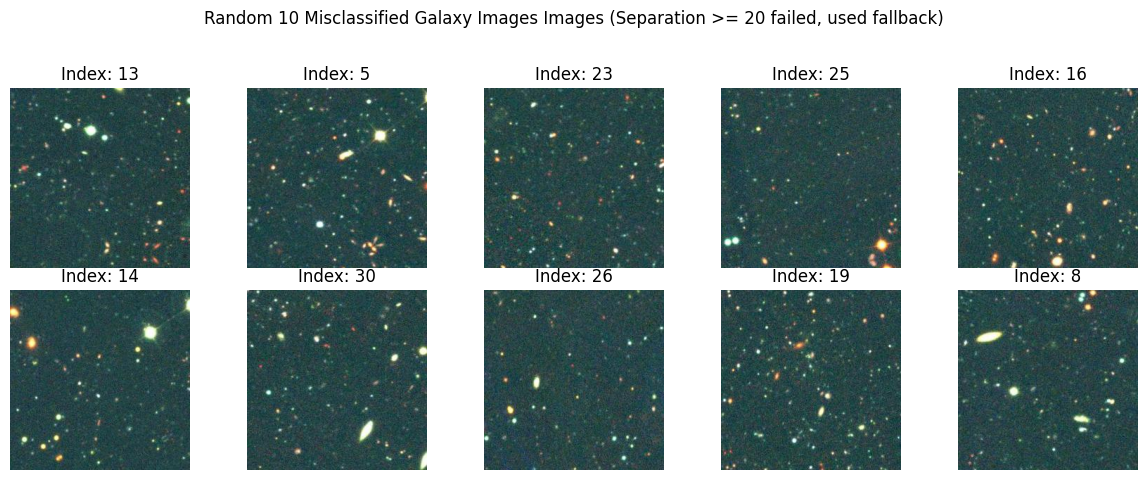

In [15]:
model_simpler = keras.models.load_model('final_models/blue_blob_galaxy_ResNet50V2_nohead.keras')
evaluator = ModelEvaluator(model_simpler, 0.5)  
evaluator.evaluate(
    blob_dir="blue_blob_test_images_subset",
    galaxy_dir="galaxies_test_images_subset",
    X_test=X_test_resnet, 
    y_test=y_test_all,
    num_to_plot=10,
    min_separation=20)

2025-05-05 22:39:19.553736: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2025-05-05 22:39:19.553799: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-05-05 22:39:19.553803: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-05-05 22:39:19.553825: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-05-05 22:39:19.553841: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Attempting to load JPEG images from: blue_blob_test_images_subset using TensorFlow/Keras
Expecting images of size: (256, 256)
Found 414 items in the directory. Processing valid JPEGs...

------------------------------------
Image loading successful!
Loaded 414 images.
Final NumPy array shape: (414, 256, 256, 3)
Data type of array elements: uint8
------------------------------------
Attempting to load JPEG images from: galaxies_test_images_subset using TensorFlow/Keras
Expecting images of size: (256, 256)
Found 354 items in the directory. Processing valid JPEGs...

------------------------------------
Image loading successful!
Loaded 354 images.
Final NumPy array shape: (354, 256, 256, 3)
Data type of array elements: uint8
------------------------------------
Galaxy images shape: (354, 256, 256, 3), dtype: float32
Blue-blob images shape: (414, 256, 256, 3), dtype: float32
Total test samples: 768


2025-05-05 22:39:21.982405: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 241ms/step


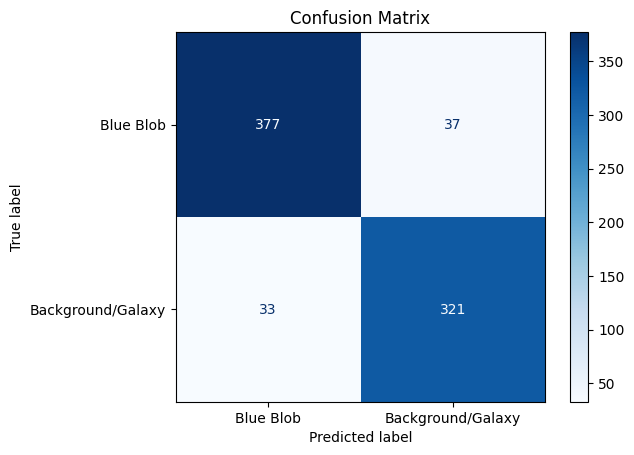

                   precision    recall  f1-score   support

        Blue Blob       0.92      0.91      0.92       414
Background/Galaxy       0.90      0.91      0.90       354

         accuracy                           0.91       768
        macro avg       0.91      0.91      0.91       768
     weighted avg       0.91      0.91      0.91       768

37 misclassified samples (true=0→pred=1)


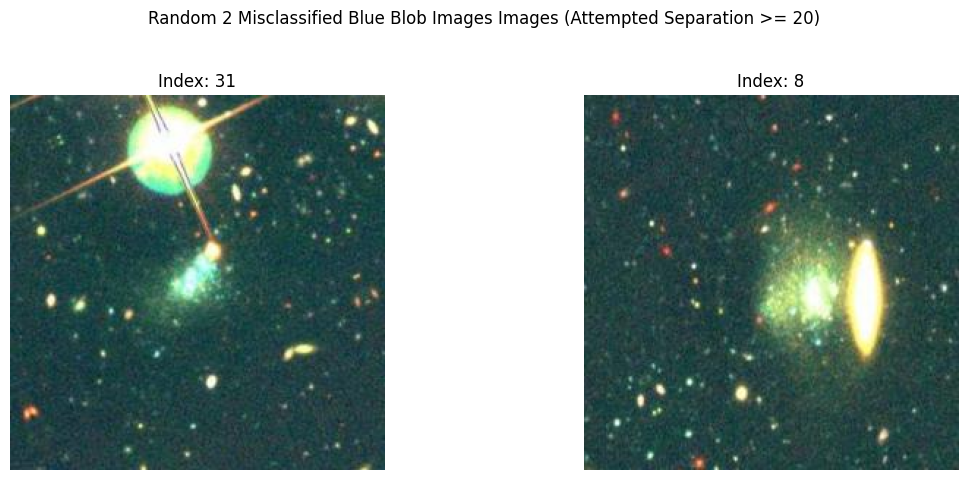

33 misclassified samples (true=1→pred=0)


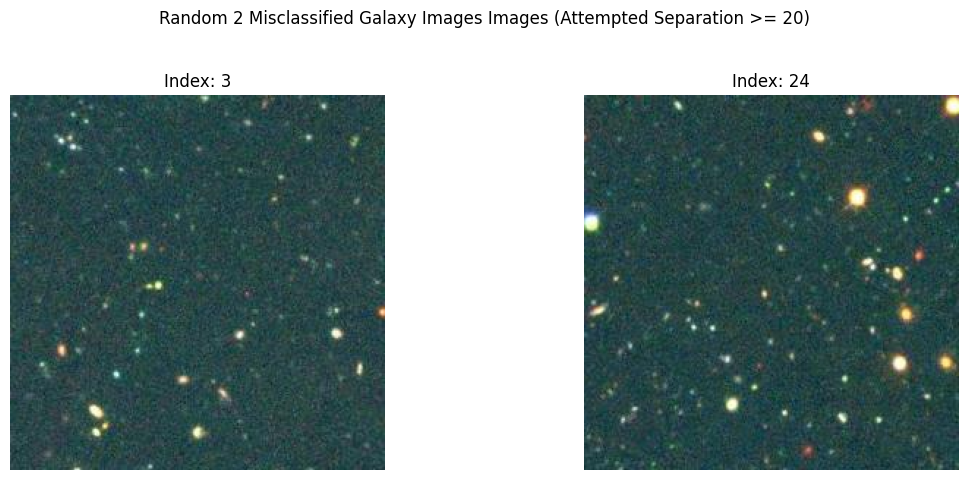

In [ ]:
model_simpler_fine_tunes = keras.models.load_model('final_models/blue_blob_galaxy_ResNet50V2_nohead_fine_tune.keras')
evaluator = ModelEvaluator(model_simpler_fine_tunes, 0.5)  
evaluator.evaluate(
    blob_dir="blue_blob_test_images_subset",
    galaxy_dir="galaxies_test_images_subset",
    X_test=X_test_resnet, 
    y_test=y_test_all,
    num_to_plot=2,
    min_separation=20)
##

## EffecientNet


Attempting to load JPEG images from: blue_blob_test_images_subset using TensorFlow/Keras
Expecting images of size: (256, 256)
Found 414 items in the directory. Processing valid JPEGs...

------------------------------------
Image loading successful!
Loaded 414 images.
Final NumPy array shape: (414, 256, 256, 3)
Data type of array elements: uint8
------------------------------------
Attempting to load JPEG images from: galaxies_test_images_subset using TensorFlow/Keras
Expecting images of size: (256, 256)
Found 354 items in the directory. Processing valid JPEGs...

------------------------------------
Image loading successful!
Loaded 354 images.
Final NumPy array shape: (354, 256, 256, 3)
Data type of array elements: uint8
------------------------------------
Galaxy images shape: (354, 256, 256, 3), dtype: float32
Blue-blob images shape: (414, 256, 256, 3), dtype: float32
Total test samples: 768
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 397ms/step


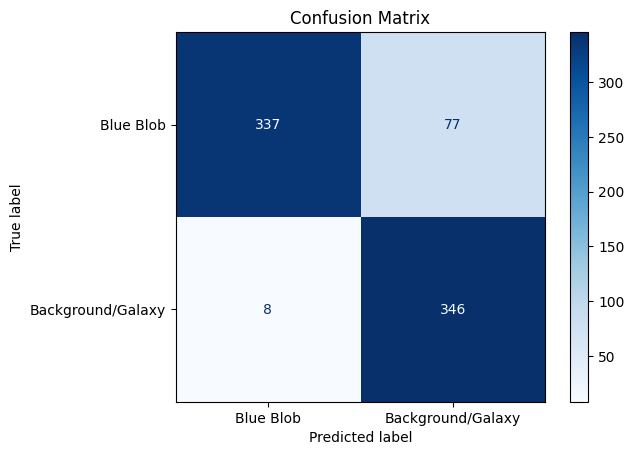

                   precision    recall  f1-score   support

        Blue Blob       0.98      0.81      0.89       414
Background/Galaxy       0.82      0.98      0.89       354

         accuracy                           0.89       768
        macro avg       0.90      0.90      0.89       768
     weighted avg       0.90      0.89      0.89       768

77 misclassified samples (true=0→pred=1)


/Users/swapnaneeldey/Desktop/MATH496T/Blue_blobs_GenAI/plotting_random_images.py:53: UserWarning: Could only find 3 indices with separation >= 20. Falling back to simple random sampling for the remaining.
  warnings.warn(f"Could only find {len(selected_indices)} indices with separation >= {min_separation}. "


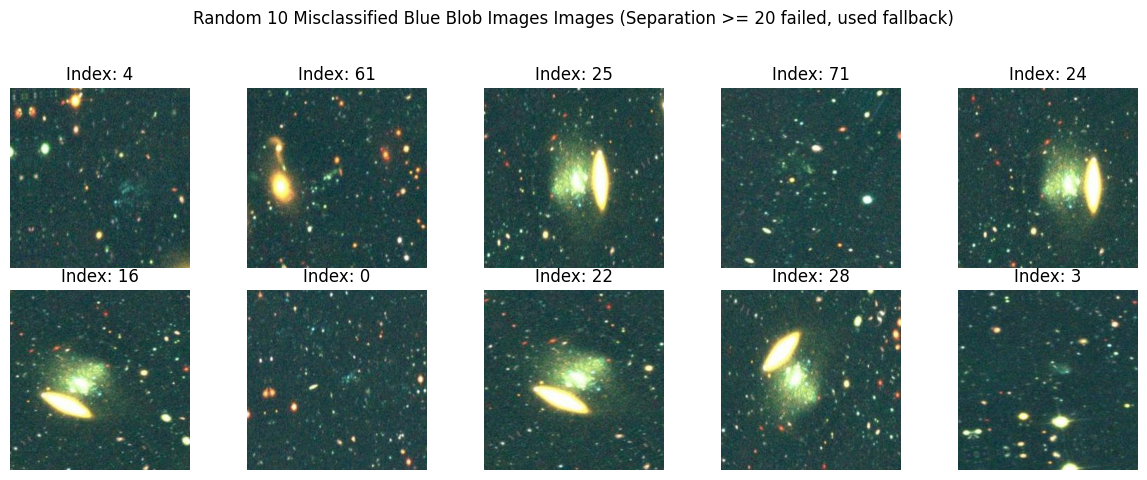

8 misclassified samples (true=1→pred=0)


/Users/swapnaneeldey/Desktop/MATH496T/Blue_blobs_GenAI/plotting_random_images.py:26: UserWarning: Requested 10 images, but only 8 available. Plotting all.
  warnings.warn(f"Requested {num_to_plot} images, but only {num_images} available. Plotting all.")


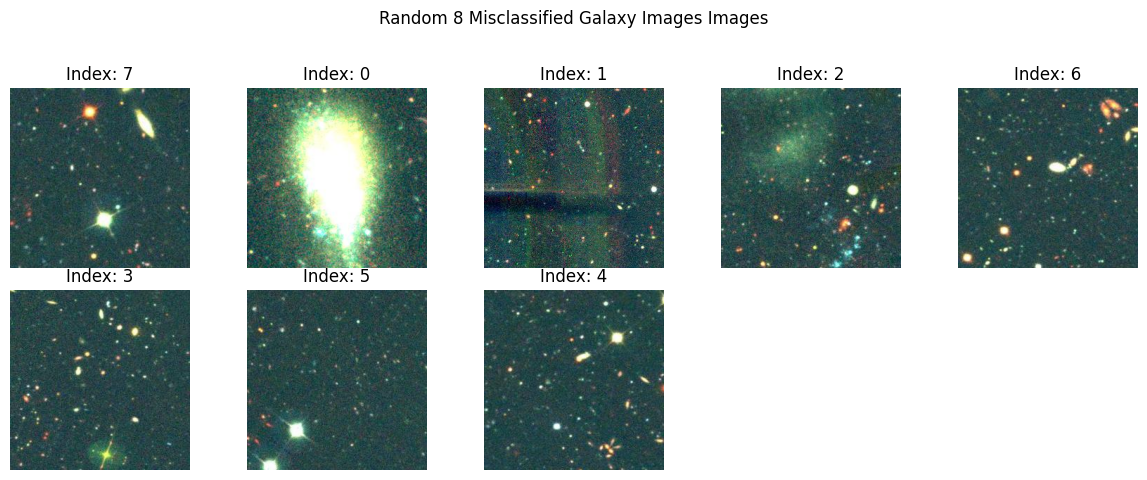

In [7]:
model_effecient_one_layer = keras.models.load_model('final_models/blue_blob_galaxy_efficientB3_mlp.keras')
evaluator = ModelEvaluator(model_effecient_one_layer, 0.5)  
evaluator.evaluate(
    blob_dir="blue_blob_test_images_subset",
    galaxy_dir="galaxies_test_images_subset",
    X_test=X_test_all,
    y_test=y_test_all,
    num_to_plot=10,
    min_separation=20)

24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 397ms/step


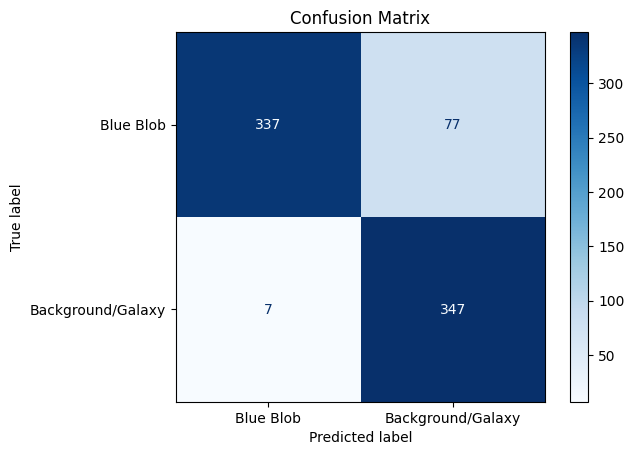

                   precision    recall  f1-score   support

        Blue Blob       0.98      0.81      0.89       414
Background/Galaxy       0.82      0.98      0.89       354

         accuracy                           0.89       768
        macro avg       0.90      0.90      0.89       768
     weighted avg       0.91      0.89      0.89       768



In [8]:
model_effecient_one_layer_fine = keras.models.load_model('final_models/blue_blob_galaxy_efficientB3_mlp_fine_tune.keras')
evaluator = ModelEvaluator(model_effecient_one_layer_fine, 0.5)
evaluator.predict_and_report(
    X_test_all, y_test_all)

## ResNet101

Attempting to load JPEG images from: blue_blob_test_images_subset using TensorFlow/Keras
Expecting images of size: (256, 256)
Found 414 items in the directory. Processing valid JPEGs...

------------------------------------
Image loading successful!
Loaded 414 images.
Final NumPy array shape: (414, 256, 256, 3)
Data type of array elements: uint8
------------------------------------
Attempting to load JPEG images from: galaxies_test_images_subset using TensorFlow/Keras
Expecting images of size: (256, 256)
Found 354 items in the directory. Processing valid JPEGs...

------------------------------------
Image loading successful!
Loaded 354 images.
Final NumPy array shape: (354, 256, 256, 3)
Data type of array elements: uint8
------------------------------------
Galaxy images shape: (354, 256, 256, 3), dtype: float32
Blue-blob images shape: (414, 256, 256, 3), dtype: float32
Total test samples: 768
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 424ms/step


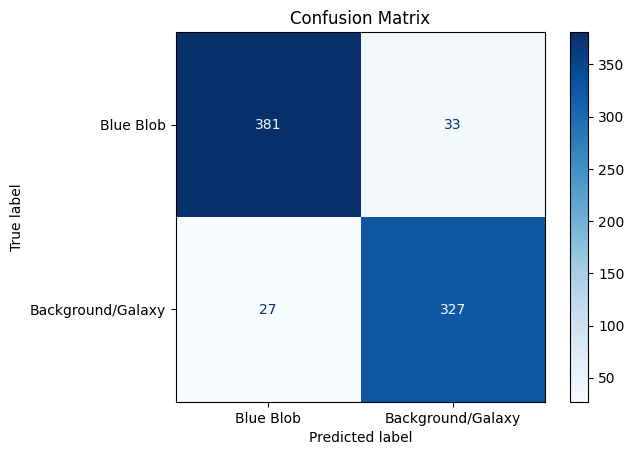

                   precision    recall  f1-score   support

        Blue Blob       0.93      0.92      0.93       414
Background/Galaxy       0.91      0.92      0.92       354

         accuracy                           0.92       768
        macro avg       0.92      0.92      0.92       768
     weighted avg       0.92      0.92      0.92       768

33 misclassified samples (true=0→pred=1)


/Users/swapnaneeldey/Desktop/MATH496T/Blue_blobs_GenAI/plotting_random_images.py:53: UserWarning: Could only find 2 indices with separation >= 20. Falling back to simple random sampling for the remaining.
  warnings.warn(f"Could only find {len(selected_indices)} indices with separation >= {min_separation}. "


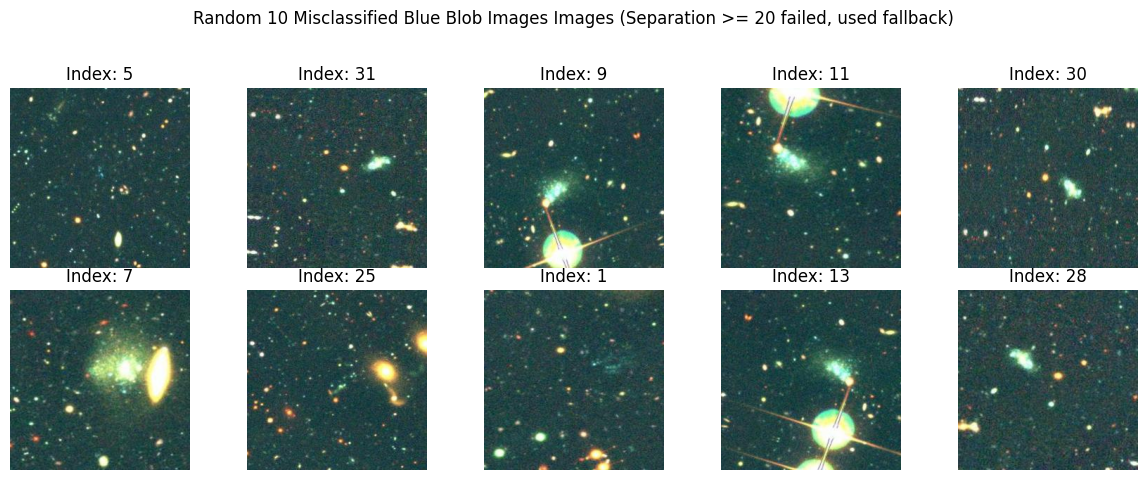

27 misclassified samples (true=1→pred=0)


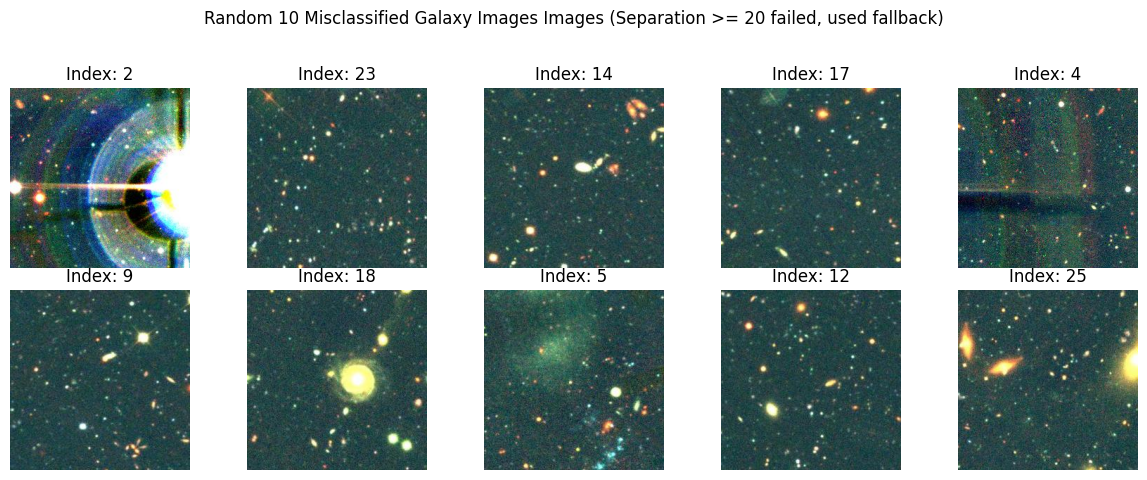

In [11]:
resnet101 = keras.models.load_model('resnet101/epoch_20.keras')
evaluator = ModelEvaluator(resnet101, 0.5)
evaluator.evaluate(
    blob_dir="blue_blob_test_images_subset",
    galaxy_dir="galaxies_test_images_subset",
    X_test= X_test_resnet,
    y_test= y_test_all,
    num_to_plot=10,
    min_separation=20)


Attempting to load JPEG images from: blue_blob_test_images_subset using TensorFlow/Keras
Expecting images of size: (256, 256)
Found 414 items in the directory. Processing valid JPEGs...

------------------------------------
Image loading successful!
Loaded 414 images.
Final NumPy array shape: (414, 256, 256, 3)
Data type of array elements: uint8
------------------------------------
Attempting to load JPEG images from: galaxies_test_images_subset using TensorFlow/Keras
Expecting images of size: (256, 256)
Found 354 items in the directory. Processing valid JPEGs...

------------------------------------
Image loading successful!
Loaded 354 images.
Final NumPy array shape: (354, 256, 256, 3)
Data type of array elements: uint8
------------------------------------
Galaxy images shape: (354, 256, 256, 3), dtype: float32
Blue-blob images shape: (414, 256, 256, 3), dtype: float32
Total test samples: 768
24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 430ms/step


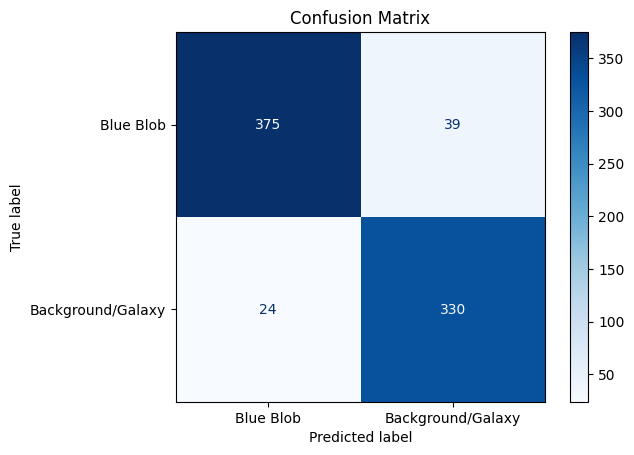

                   precision    recall  f1-score   support

        Blue Blob       0.94      0.91      0.92       414
Background/Galaxy       0.89      0.93      0.91       354

         accuracy                           0.92       768
        macro avg       0.92      0.92      0.92       768
     weighted avg       0.92      0.92      0.92       768

39 misclassified samples (true=0→pred=1)


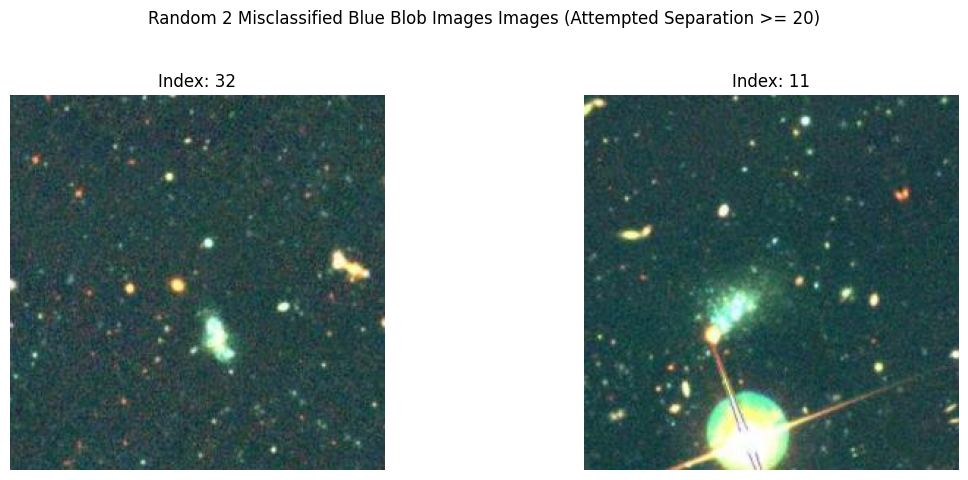

24 misclassified samples (true=1→pred=0)


/Users/swapnaneeldey/Desktop/MATH496T/Blue_blobs_GenAI/plotting_random_images.py:53: UserWarning: Could only find 1 indices with separation >= 20. Falling back to simple random sampling for the remaining.
  warnings.warn(f"Could only find {len(selected_indices)} indices with separation >= {min_separation}. "


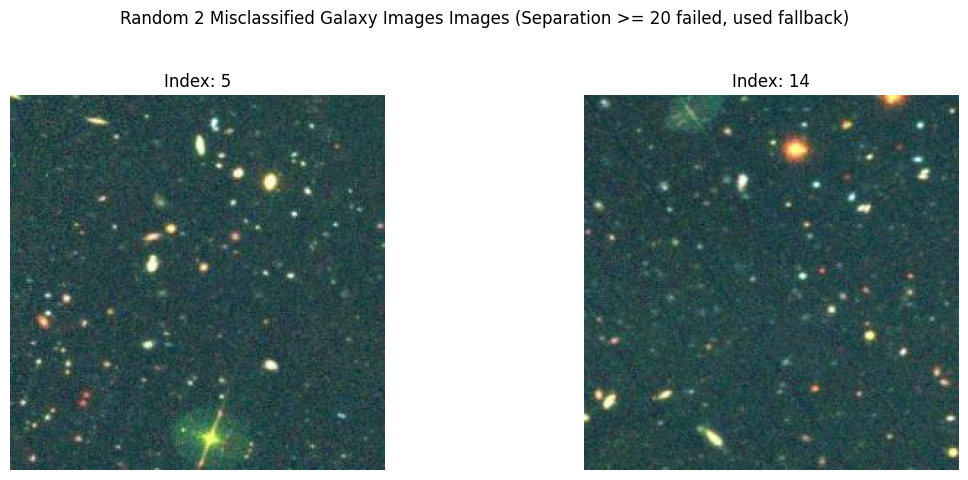

In [12]:
resnet101 = keras.models.load_model('final_models/blue_blob_galaxy_ResNet101V2_fine_tune.keras')
evaluator = ModelEvaluator(resnet101, 0.5)
evaluator.evaluate(
    blob_dir="blue_blob_test_images_subset",
    galaxy_dir="galaxies_test_images_subset",
    X_test= X_test_resnet,
    y_test= y_test_all,
    num_to_plot=2,
    min_separation=20)